In [1]:
# datasets/celeb_masked.py
import os
import random
from PIL import Image

import torch
from torch.utils.data import Dataset
from torchvision import transforms

In [2]:
# ------------------ Configurable defaults ------------------
DEFAULT_SIZE = (128, 128)   # same as you used previously
# image transform: to tensor and normalize to [-1,1] (your training code expects this)
default_image_transform = transforms.Compose([
    transforms.Resize(DEFAULT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])
# mask transform: keep in [0,1], do NOT normalize
default_mask_transform = transforms.Compose([
    transforms.Resize(DEFAULT_SIZE, interpolation=Image.NEAREST),
    transforms.ToTensor()   # yields CxHxW in [0,1]
])
# -----------------------------------------------------------

class CelebAMaskedDataset(Dataset):
    """
    Dataset that returns (observed, mask, unobserved, original, filename)
    - root: path that contains 'train' and 'test' subfolders with the 7 subfolders
    - split: 'train' or 'test'
    - mask_type: 'horizontal'|'vertical'|'random'|'both'
    - image_transform / mask_transform: torchvision transforms
    """
    def __init__(self, root, split="train", mask_type="random",
                 image_transform=None, mask_transform=None, seed=None):
        assert split in ("train", "test", "valid", "val"), "split must be 'train' or 'test' (or 'valid')"
        self.root = root
        self.split = "valid" if split == "val" else split
        self.mask_type = mask_type
        self.split_dir = os.path.join(root, self.split)
        self.image_transform = image_transform or default_image_transform
        self.mask_transform = mask_transform or default_mask_transform

        # folders we expect under split_dir
        expected = ["original",
                    "horizontal_mask", "horizontal_mask_observed_image", "horizontal_mask_unobserved_image",
                    "vertical_mask", "vertical_mask_observed_image", "vertical_mask_unobserved_image"]
        for f in expected:
            if not os.path.isdir(os.path.join(self.split_dir, f)):
                raise FileNotFoundError(f"Expected folder missing: {os.path.join(self.split_dir, f)}")

        # list images from original folder (keeps original names)
        self.filenames = sorted([
            f for f in os.listdir(os.path.join(self.split_dir, "original"))
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])
        if seed is not None:
            random.seed(seed)

    def __len__(self):
        return len(self.filenames)

    def _load_image(self, folder, filename):
        path = os.path.join(self.split_dir, folder, filename)
        img = Image.open(path).convert("RGB")
        return img

    def _load_mask_tensor(self, folder, filename):
        """
        Returns mask tensor with shape (3,H,W) and values {0.,1.}
        Works if stored mask is single channel or 3-channel.
        """
        path = os.path.join(self.split_dir, folder, filename)
        m = Image.open(path).convert("RGB")   # ensure 3 channels for consistent behavior
        m_t = self.mask_transform(m)          # CxHxW in [0,1]
        # Some mask saving pipelines may yield small interpolation values; threshold
        m_t = (m_t > 0.5).float()
        return m_t

    def __getitem__(self, idx):
        fname = self.filenames[idx]

        # load original
        orig_pil = self._load_image("original", fname)
        orig = self.image_transform(orig_pil)   # 3xHxW normalized to [-1,1]

        # decide mask folder(s)
        if self.mask_type == "horizontal":
            mask_folder = "horizontal_mask"
            mask = self._load_mask_tensor(mask_folder, fname)
        elif self.mask_type == "vertical":
            mask_folder = "vertical_mask"
            mask = self._load_mask_tensor(mask_folder, fname)
        elif self.mask_type == "random":
            # choose per-sample
            mask_folder = random.choice(["horizontal_mask", "vertical_mask"])
            mask = self._load_mask_tensor(mask_folder, fname)
        elif self.mask_type == "both":
            # return both masks concatenated along channel dim: mask has 6 channels
            m_h = self._load_mask_tensor("horizontal_mask", fname)
            m_v = self._load_mask_tensor("vertical_mask", fname)
            mask = torch.cat([m_h, m_v], dim=0)   # 6 x H x W
        else:
            raise ValueError("Unknown mask_type: choose 'horizontal','vertical','random','both'")

        # If mask is 6-channel (both), we will produce observed/unobserved per-channel semantics
        if mask.shape[0] == 3:
            observed = orig * mask
            unobserved = orig * (1.0 - mask)
        elif mask.shape[0] == 6:
            # If both masks concatenated, split them and create observed/unobserved for each then concat
            m_h = mask[:3]
            m_v = mask[3:]
            # You might want to return both observed versions; for simplicity, we concatenate along channel
            # observed = [orig * m_h, orig * m_v] -> 6 channels
            observed = torch.cat([orig * m_h, orig * m_v], dim=0)
            unobserved = torch.cat([orig * (1 - m_h), orig * (1 - m_v)], dim=0)
        else:
            raise RuntimeError("Unexpected mask channels: {}".format(mask.shape[0]))

        return {
            "observed": observed,       # 3xHxW (or 6xHxW if both)
            "mask": mask,               # 3xHxW (or 6xHxW if both)
            "unobserved": unobserved,   # 3xHxW (or 6xHxW if both)
            "original": orig,           # 3xHxW normalized
            "filename": fname
        }

# ---------------- convenience function to create DataLoader ----------------
from torch.utils.data import DataLoader

def get_celeb_dataloader(root, split="train", mask_type="random", batch_size=16,
                         shuffle=True, num_workers=4, pin_memory=True, seed=None,
                         image_transform=None, mask_transform=None):
    ds = CelebAMaskedDataset(root=root, split=split, mask_type=mask_type,
                             image_transform=image_transform, mask_transform=mask_transform, seed=seed)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                        num_workers=num_workers, pin_memory=pin_memory)
    return loader, ds


In [3]:
ROOT = "/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/Data/CelebA/split_data"

mask_type = "horizontal"

train_loader, train_ds = get_celeb_dataloader(ROOT, split="train", mask_type=mask_type,
                                              batch_size=16, shuffle=True, num_workers=0, pin_memory=False)
test_loader, test_ds = get_celeb_dataloader(ROOT, split="test", mask_type=mask_type,
                                            batch_size=16, shuffle=False, num_workers=0, pin_memory=False)


In [4]:
train_loader

In [5]:
train_ds

In [6]:
train_ds[0]

{'observed': tensor([[[-0.1922, -0.2078, -0.2706,  ...,  0.8353,  0.8118,  0.8431],
          [-0.1922, -0.2078, -0.2706,  ...,  0.8353,  0.8118,  0.8431],
          [-0.1922, -0.2078, -0.2706,  ...,  0.8353,  0.8118,  0.8510],
          ...,
          [ 0.0353,  0.0431,  0.0510,  ...,  0.0431,  0.6627,  0.2863],
          [ 0.0196, -0.0196, -0.0196,  ..., -0.1137,  0.2706, -0.4196],
          [ 0.0196,  0.0353,  0.0275,  ..., -0.2627, -0.3333, -0.4824]],
 
         [[-0.7569, -0.7176, -0.6784,  ..., -0.6314, -0.6706, -0.6549],
          [-0.7569, -0.7176, -0.6784,  ..., -0.6314, -0.6706, -0.6549],
          [-0.7569, -0.7176, -0.6784,  ..., -0.6314, -0.6706, -0.6471],
          ...,
          [-0.5294, -0.5294, -0.5216,  ..., -0.1529,  0.4745,  0.1216],
          [-0.5294, -0.5608, -0.5608,  ..., -0.3020,  0.0824, -0.5608],
          [-0.4980, -0.4902, -0.4980,  ..., -0.4431, -0.5216, -0.6706]],
 
         [[ 0.1843,  0.2627,  0.3490,  ...,  0.2706,  0.2314,  0.2549],
          [ 0.18

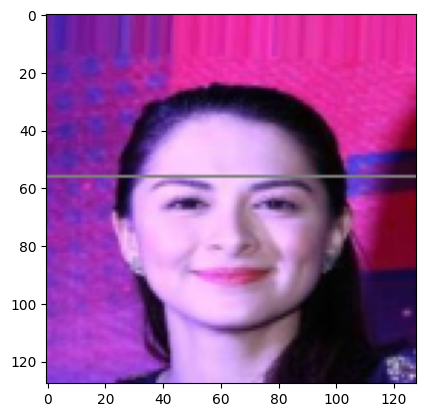

In [7]:
import matplotlib.pyplot as plt

plt.imshow(train_ds[0]['observed'].permute(1,2,0).numpy() * 0.5 + 0.5)
plt.show()

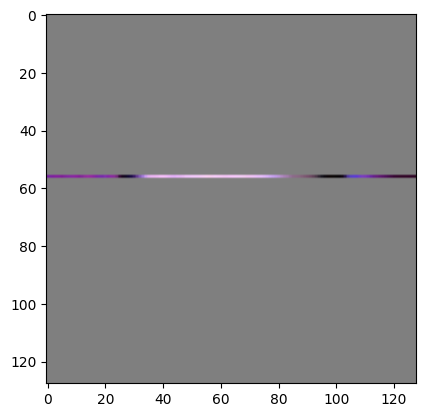

In [8]:
plt.imshow(train_ds[0]['unobserved'].permute(1,2,0).numpy() * 0.5 + 0.5)
plt.show()

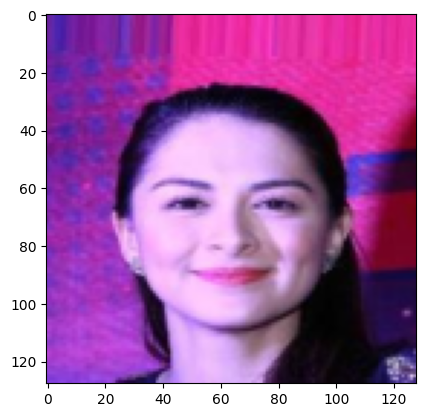

In [9]:
plt.imshow(train_ds[0]['original'].permute(1,2,0).numpy() * 0.5 + 0.5)
plt.show()

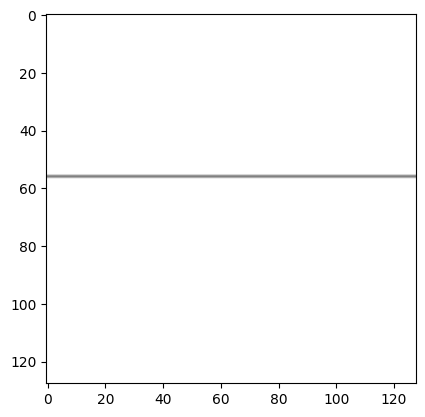

In [10]:
plt.imshow(train_ds[0]['mask'].permute(1,2,0).numpy() * 0.5 + 0.5)
plt.show()


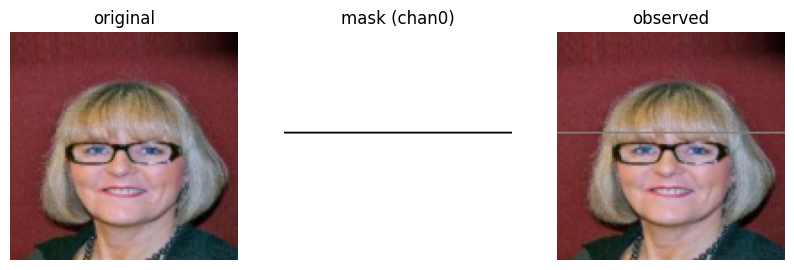

In [11]:
import matplotlib.pyplot as plt
sample = next(iter(train_loader))
orig = sample['original'][0].permute(1,2,0).numpy()  # still normalized to [-1,1]
orig = (orig * 0.5) + 0.5  # convert to [0,1]
mask = sample['mask'][0][0].numpy()  # first channel
obs = sample['observed'][0].permute(1,2,0).numpy()
obs = (obs * 0.5) + 0.5

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(orig); plt.title("original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("mask (chan0)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(obs); plt.title("observed"); plt.axis('off')
plt.show()


In [12]:
len(train_ds)

162079

In [13]:
len(test_ds)

40520

In [14]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

In [15]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# ---------------- NN utility classes ----------------
class ResBlock(nn.Module):
    def __init__(self, outer_dim, inner_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(outer_dim),
            nn.LeakyReLU(),
            nn.Conv2d(outer_dim, inner_dim, 1),
            nn.BatchNorm2d(inner_dim),
            nn.LeakyReLU(),
            nn.Conv2d(inner_dim, inner_dim, 3, 1, 1),
            nn.BatchNorm2d(inner_dim),
            nn.LeakyReLU(),
            nn.Conv2d(inner_dim, outer_dim, 1),
        )
    def forward(self, x):
        return x + self.net(x)

class SkipConnection(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.inner = nn.Sequential(*args)
    def forward(self, x):
        return x + self.inner(x)

class MemoryLayer(nn.Module):
    """
    Stores activations keyed by `id` on forward.
    If constructed with output=True, retrieves stored activation and either concatenates or adds.
    This is the same MemoryLayer design from your code.
    """
    storage = {}
    def __init__(self, id, output=False, add=False):
        super().__init__()
        self.id = id
        self.output = output
        self.add = add
    def forward(self, x):
        if not self.output:
            MemoryLayer.storage[self.id] = x
            return x
        else:
            stored = MemoryLayer.storage[self.id]
            if not self.add:
                return torch.cat([x, stored], 1)
            else:
                return x + stored

# ------------------- distribution helpers -------------------
def parse_params_to_mu_sigma(params, min_sigma=1e-2):
    """
    params: (B, 2*C, H, W)
    Returns:
      mu:    (B,C,H,W)
      sigma: (B,C,H,W)   with safe lower bound
    """
    B, C2, H, W = params.shape
    assert C2 % 2 == 0, "channels in params must be even"
    C = C2 // 2

    mu = params[:, :C, :, :].contiguous()
    sigma_params = params[:, C:, :, :].contiguous()

    sigma = F.softplus(sigma_params) + 1e-2
    sigma = sigma.clamp(min=min_sigma, max=50.0)
    return mu, sigma

def sample_from_mu_sigma(mu, sigma):
    eps = torch.randn_like(mu)
    return mu + eps * sigma

def kl_normal(mu_q, sigma_q, mu_p, sigma_p):
    # KL between two diagonal Gaussians: sum over dims (per-batch)
    sq = sigma_q
    sp = sigma_p
    term = (
        torch.log(sp) - torch.log(sq)
        + (sq**2 + (mu_q - mu_p)**2) / (2 * sp**2)
        - 0.5
    )
    return term.view(term.size(0), -1).sum(-1)

# ------------------- block helper -------------------
def MLPBlock(dim):
    return SkipConnection(
        nn.BatchNorm2d(dim),
        nn.LeakyReLU(),
        nn.Conv2d(dim, dim, 1)
    )

# ------------------- networks (exact architecture provided) -------------------
# Proposal network (q)
proposal_network = nn.Sequential(
    nn.Conv2d(6, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    nn.AvgPool2d(2, 2),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    nn.AvgPool2d(2, 2), nn.Conv2d(8, 16, 1),
    ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8),
    nn.AvgPool2d(2, 2), nn.Conv2d(16, 32, 1),
    ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16),
    nn.AvgPool2d(2, 2), nn.Conv2d(32, 64, 1),
    ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32),
    nn.AvgPool2d(2, 2), nn.Conv2d(64, 128, 1),
    ResBlock(128, 64), ResBlock(128, 64),
    ResBlock(128, 64), ResBlock(128, 64),
    nn.AvgPool2d(2, 2), nn.Conv2d(128, 256, 1),
    ResBlock(256, 128), ResBlock(256, 128),
    ResBlock(256, 128), ResBlock(256, 128),
    nn.AvgPool2d(2, 2), nn.Conv2d(256, 512, 1),
    MLPBlock(512), MLPBlock(512), MLPBlock(512), MLPBlock(512),
)

# Prior network (p)
prior_network = nn.Sequential(
    MemoryLayer('#0'),
    nn.Conv2d(6, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    MemoryLayer('#1'),
    nn.AvgPool2d(2, 2),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    MemoryLayer('#2'),
    nn.AvgPool2d(2, 2), nn.Conv2d(8, 16, 1),
    ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8),
    MemoryLayer('#3'),
    nn.AvgPool2d(2, 2), nn.Conv2d(16, 32, 1),
    ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16),
    MemoryLayer('#4'),
    nn.AvgPool2d(2, 2), nn.Conv2d(32, 64, 1),
    ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32),
    MemoryLayer('#5'),
    nn.AvgPool2d(2, 2), nn.Conv2d(64, 128, 1),
    ResBlock(128, 64), ResBlock(128, 64),
    ResBlock(128, 64), ResBlock(128, 64),
    MemoryLayer('#6'),
    nn.AvgPool2d(2, 2), nn.Conv2d(128, 256, 1),
    ResBlock(256, 128), ResBlock(256, 128),
    ResBlock(256, 128), ResBlock(256, 128),
    MemoryLayer('#7'),
    nn.AvgPool2d(2, 2), nn.Conv2d(256, 512, 1),
    MLPBlock(512), MLPBlock(512), MLPBlock(512), MLPBlock(512),
)

# Generative network (decoder)
generative_network = nn.Sequential(
    nn.Conv2d(256, 256, 1),
    MLPBlock(256), MLPBlock(256), MLPBlock(256), MLPBlock(256),
    nn.Conv2d(256, 128, 1), nn.Upsample(scale_factor=2),
    MemoryLayer('#7', output=True), nn.Conv2d(384, 128, 1),
    ResBlock(128, 64), ResBlock(128, 64),
    ResBlock(128, 64), ResBlock(128, 64),
    nn.Conv2d(128, 64, 1), nn.Upsample(scale_factor=2),
    MemoryLayer('#6', output=True), nn.Conv2d(192, 64, 1),
    ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32), ResBlock(64, 32),
    nn.Conv2d(64, 32, 1), nn.Upsample(scale_factor=2),
    MemoryLayer('#5', output=True), nn.Conv2d(96, 32, 1),
    ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16), ResBlock(32, 16),
    nn.Conv2d(32, 16, 1), nn.Upsample(scale_factor=2),
    MemoryLayer('#4', output=True), nn.Conv2d(48, 16, 1),
    ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8), ResBlock(16, 8),
    nn.Conv2d(16, 8, 1), nn.Upsample(scale_factor=2),
    MemoryLayer('#3', output=True), nn.Conv2d(24, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    nn.Upsample(scale_factor=2),
    MemoryLayer('#2', output=True), nn.Conv2d(16, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    nn.Upsample(scale_factor=2),
    MemoryLayer('#1', output=True), nn.Conv2d(16, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    MemoryLayer('#0', output=True), nn.Conv2d(14, 8, 1),
    ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8), ResBlock(8, 8),
    nn.Conv2d(8, 6, 1),
)

# ------------------- optimizer helper -------------------
def optimizer(parameters):
    """Return an Adam optimizer for the model parameters (lr=2e-4)."""
    return Adam(parameters, lr=2e-4)

# ------------------- VAEAC wrapper -------------------
class VAEAC(nn.Module):
    def __init__(self, rec_log_prob, proposal_network, prior_network, generative_network, sigma_mu=1e4, sigma_sigma=1e-4):
        super().__init__()
        self.rec_log_prob = rec_log_prob
        self.proposal_network = proposal_network
        self.prior_network = prior_network
        self.generative_network = generative_network
        self.sigma_mu = sigma_mu
        self.sigma_sigma = sigma_sigma

    def make_observed(self, batch, mask):
        observed = batch.clone()
        observed[mask.bool()] = 0
        return observed

    def make_latent_distributions(self, batch, mask, no_proposal=False):
        observed = self.make_observed(batch, mask)
        if no_proposal:
            proposal = None
        else:
            full_info = torch.cat([batch, mask], 1)
            proposal_params = self.proposal_network(full_info)
            mu_p, sigma_p = parse_params_to_mu_sigma(proposal_params)
            proposal = (mu_p, sigma_p)
        prior_params = self.prior_network(torch.cat([observed, mask], 1))
        mu_prior, sigma_prior = parse_params_to_mu_sigma(prior_params)
        prior = (mu_prior, sigma_prior)
        return proposal, prior

    def prior_regularization(self, prior):
        mu = prior[0].view(prior[0].shape[0], -1)
        sigma = prior[1].view(prior[1].shape[0], -1)
        mu_reg = -(mu ** 2).sum(-1) / (2 * self.sigma_mu ** 2)
        sigma_reg = (sigma.log() - sigma).sum(-1) * self.sigma_sigma
        return mu_reg + sigma_reg

    def batch_vlb(self, batch, mask):
        proposal, prior = self.make_latent_distributions(batch, mask)
        mu_q, sigma_q = proposal
        mu_p, sigma_p = prior
        prior_reg = self.prior_regularization(prior)
        z = sample_from_mu_sigma(mu_q.float(), sigma_q.float())
        z = torch.clamp(z, -10.0, 10.0)     # stability fix

        # feed z into generative_network (z is 4D)
        rec_params = self.generative_network(z)
        rec_params = rec_params.clamp(-20, 20)   # avoid INF/NaN in decoder outputs
        mu_img, sigma_img = parse_params_to_mu_sigma(rec_params)

        gt = batch
        tol = 1e-6
        term = -0.5 * ((gt - mu_img) / (sigma_img + tol))**2 - torch.log(sigma_img + tol) - 0.5 * math.log(2*math.pi)
        # recon_log_prob over masked region (mask==1 indicates region to evaluate)
        recon_log_prob = (term * mask).view(term.size(0), -1).sum(-1)

        kl = kl_normal(mu_q, sigma_q, mu_p, sigma_p)
        kl = torch.clamp(kl, -1e6, 1e6)     # safety

        vlb = recon_log_prob - kl + prior_reg

        if torch.isnan(vlb).any():
            # safe fallback: avoid breaking training
            print("⚠️ WARNING: NaN detected in VLB — returning zeros.")
            return torch.zeros_like(vlb)

        return vlb

# ------------------- utilities -------------------
def clear_memory_layers():
    """Call before a forward to clear MemoryLayer.storage between passes."""
    try:
        MemoryLayer.storage.clear()
    except Exception:
        MemoryLayer.storage = {}

# ------------------- factory -------------------
def create_vaeac(device=None, device_name=None):
    """
    Create VAEAC model, move to device, return all major objects.
    Returns:
      model (VAEAC instance),
      proposal_network,
      prior_network,
      generative_network,
      optimizer_fn (callable expecting model.parameters())
    """
    # instantiate wrapper model using the pre-defined networks
    model = VAEAC(None, proposal_network, prior_network, generative_network)
    # move networks & model to device
    if device_name is not None:
        device = torch.device(device_name)
    device = device or torch.device("cpu")
    proposal_network.to(device)
    prior_network.to(device)
    generative_network.to(device)
    model.to(device)

    return model, proposal_network, prior_network, generative_network, optimizer

# ------------------- optional quick sanity check function -------------------
def sanity_check_forward(device=torch.device("cpu")):
    """
    Runs a quick forward to check tensor shapes. Useful when changing image size.
    Expects inputs: batch (B x 3 x H x W), mask (B x 3 x H x W)
    We'll construct random tensors with H=W=128 by default.
    """
    B, C, H, W = 2, 3, 128, 128
    x = torch.randn(B, C, H, W).to(device)
    # mask==1 indicates region to evaluate: random binary
    mask = (torch.rand(B, C, H, W) > 0.5).float().to(device)

    clear_memory_layers()
    model = VAEAC(None, proposal_network, prior_network, generative_network).to(device)
    proposal, prior = model.make_latent_distributions(x, mask)
    mu_q, sigma_q = proposal
    mu_p, sigma_p = prior
    # sample z and decode
    z = sample_from_mu_sigma(mu_q, sigma_q)
    rec_params = generative_network(z)
    mu_img, sigma_img = parse_params_to_mu_sigma(rec_params)
    print("sanity check shapes:")
    print("mu_q", mu_q.shape, "sigma_q", sigma_q.shape)
    print("mu_p", mu_p.shape, "sigma_p", sigma_p.shape)
    print("decoded mu_img", mu_img.shape, "sigma_img", sigma_img.shape)

In [17]:
model, q_net, p_net, g_net, optimizer_fn = create_vaeac(device=DEVICE)
opt = optimizer_fn(model.parameters())
scaler = torch.cuda.amp.GradScaler()

# quick shape check
sanity_check_forward(device=DEVICE)


sanity check shapes:
mu_q torch.Size([2, 256, 1, 1]) sigma_q torch.Size([2, 256, 1, 1])
mu_p torch.Size([2, 256, 1, 1]) sigma_p torch.Size([2, 256, 1, 1])
decoded mu_img torch.Size([2, 3, 128, 128]) sigma_img torch.Size([2, 3, 128, 128])


/tmp/ipykernel_915416/2508147499.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/.venv/lib/python3.12/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [18]:
import os
import math
import time
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
from torch.cuda.amp import GradScaler, autocast

from sklearn.decomposition import PCA
import pandas as pd

In [19]:
ROOT = "/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/Data/CelebA/split_data"
RESULTS_DIR = "/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/VAEAC_celeba"
LATENT_DIR = os.path.join(RESULTS_DIR, "latents")
CKPT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LATENT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [ ]:

BATCH_SIZE = 16
EPOCHS = 50
SAVE_FIXED_COUNT = 16
VLB_SCALE = 128 * 128             # note: remove space if copying; keep as integer
VLB_SCALE = 128 * 128              # pixels scalar used to normalize loss (C omitted to match your friend)
LEARNING_RATE = 2e-4
NUM_WORKERS = 0                     # set >0 in non-notebook environment
USE_AMP = True
CHECKPOINT_EVERY = 1                # save every n epochs
SEED = 42
# -------------------------------------------

torch.manual_seed(SEED)
np.random.seed(SEED)
gc.collect()

# ---------- imports assuming you have these modules defined ----------
# from models.vaeac_model import create_vaeac, clear_memory_layers, parse_params_to_mu_sigma, sample_from_mu_sigma
# from datasets.celeb_masked import get_celeb_dataloader

# If you are running this in the same notebook, the above functions/classes are already in scope.
# Otherwise import them as modules. The script below assumes:
# - `model` is a VAEAC instance
# - `proposal_network`, `prior_network`, `generative_network` exist
# - `optimizer` helper exists (returns Adam)
# - `clear_memory_layers()`, `parse_params_to_mu_sigma`, `sample_from_mu_sigma` exist

# ---------- SETUP: model, optimizer, scaler, dataloaders ----------
# create model & networks using your factory or previously-defined globals.
# If you used create_vaeac(device) : uncomment and use that
# model, proposal_network, prior_network, generative_network, optimizer_fn = create_vaeac(device=DEVICE)
# opt = optimizer_fn(model.parameters())

# Otherwise, assuming `model`, `proposal_network`, `prior_network`, `generative_network`, `optimizer` exist in current scope:
# Move them to device and create optimizer here:
proposal_network = proposal_network.to(DEVICE)
prior_network = prior_network.to(DEVICE)
generative_network = generative_network.to(DEVICE)
model = model.to(DEVICE)
opt = optimizer(model.parameters())   # uses your optimizer helper returning Adam
scaler = GradScaler(enabled=USE_AMP)

# prepare dataloaders — uses dataset that returns dict {original, mask, ...}
train_loader, train_ds = get_celeb_dataloader(ROOT, split="train", mask_type="random",
                                              batch_size=BATCH_SIZE, shuffle=True,
                                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'),
                                              image_transform=None, mask_transform=None)
# fixed batch for visualization & latent tracking (use the first SAVE_FIXED_COUNT samples)
fixed_loader, _ = get_celeb_dataloader(ROOT, split="train", mask_type="random",
                                       batch_size=SAVE_FIXED_COUNT, shuffle=False,
                                       num_workers=0, pin_memory=False)
fixed_batch = None
for fb in fixed_loader:
    # fb is a dict per our dataset
    fixed_batch = fb["original"].to(DEVICE)
    fixed_mask_ds = fb["mask"].to(DEVICE)
    break
if fixed_batch is None:
    raise RuntimeError("Couldn't obtain fixed batch for visualization.")

# Utility: ensure mask semantics align with model (dataset: mask==1 => observed)
def dataset_to_model_mask(ds_mask):
    # model expects mask==1 where we evaluate reconstruction (missing region).
    # Our dataset has mask==1 for observed pixels -> invert
    return (1.0 - ds_mask).to(DEVICE)

# clear memory layers before forward
def _clear_memory():
    try:
        MemoryLayer.storage.clear()
    except Exception:
        MemoryLayer.storage = {}

# helper to save checkpoint
def save_checkpoint(epoch, path):
    full_model_path = os.path.join(CKPT_DIR, f"model_full_epoch_{epoch:03d}.pt")
    torch.save(model, full_model_path)

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": opt.state_dict()
    }
    if scaler is not None:
        ckpt["scaler_state"] = scaler.state_dict()
    torch.save(ckpt, path)
    
    
    print(f"Saved FULL model → {full_model_path}")
    print(f"Saved training checkpoint → {ckpt_path}")

    

# ---------- training loop ----------
all_latents = []
pca_model = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", ncols=100)
    for batch in pbar:
        imgs = batch["original"].to(DEVICE)   # B x 3 x H x W
        ds_mask = batch["mask"].to(DEVICE)    # B x 3 x H x W (1=observed)
        model_mask = dataset_to_model_mask(ds_mask)  # B x 3 x H x W (1=missing, as expected by model)

        # make sure memory cleared
        _clear_memory()

        # forward + vlb under AMP
        with autocast():
            vlb = model.batch_vlb(imgs, model_mask)   # shape (B,)
            loss = -vlb.mean() / float(VLB_SCALE)

        opt.zero_grad(set_to_none=True)
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            opt.step()

        pbar.set_postfix({"loss": f"{loss.item():.6f}"})
        epoch_loss += loss.item() * imgs.size(0)

    avg_loss = epoch_loss / len(train_ds)
    print(f"Epoch {epoch} average loss: {avg_loss:.6f}")

    # ---------- latent extraction & visualizations on fixed batch ----------
    model.eval()
    with torch.no_grad():
        # clear memory for safe forward
        _clear_memory()
        proposal, prior = model.make_latent_distributions(fixed_batch, dataset_to_model_mask(fixed_mask_ds))
        mu_q, sigma_q = proposal
        z = sample_from_mu_sigma(mu_q, sigma_q)  # B x C x h x w
        z_flat = z.view(z.size(0), -1).cpu().numpy()
        np.save(os.path.join(LATENT_DIR, f"epoch_{epoch:03d}_z_raw.npy"), z_flat)

        if pca_model is None:
            pca_model = PCA(n_components=2)
            z_pca = pca_model.fit_transform(z_flat)
        else:
            z_pca = pca_model.transform(z_flat)
        np.save(os.path.join(LATENT_DIR, f"epoch_{epoch:03d}_z_pca.npy"), z_pca)
        all_latents.append(z_pca)

        # save per-epoch PCA scatter
        plt.figure(figsize=(6,5))
        plt.scatter(z_pca[:,0], z_pca[:,1], alpha=0.7)
        plt.title(f"Latent PCA — Epoch {epoch}")
        plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(LATENT_DIR, f"epoch_{epoch:03d}_latent.png"), dpi=150)
        plt.close()

        # produce reconstructions (use proposal)
        proposal2, prior2 = model.make_latent_distributions(fixed_batch, dataset_to_model_mask(fixed_mask_ds))
        mu_q2, sigma_q2 = proposal2
        z2 = sample_from_mu_sigma(mu_q2, sigma_q2)
        rec_params = model.generative_network(z2)
        mu_img, sigma_img = parse_params_to_mu_sigma(rec_params)
        preds = mu_img
        observed = fixed_batch * (1 - dataset_to_model_mask(fixed_mask_ds))  # observed pixels
        x_hat = observed + preds * dataset_to_model_mask(fixed_mask_ds)
        x_hat = x_hat.clamp(-1, 1)

        epoch_dir = os.path.join(RESULTS_DIR, f"epoch_{epoch:03d}")
        os.makedirs(epoch_dir, exist_ok=True)
        for i in range(min(SAVE_FIXED_COUNT, x_hat.size(0))):
            sample_dir = os.path.join(epoch_dir, f"sample_{i:03d}")
            os.makedirs(sample_dir, exist_ok=True)
            # helpers to save tensors (assume normalized [-1,1])
            def tensor_to_pil(t):
                t = t.detach().cpu()
                if t.min() < -0.1:
                    t = t * 0.5 + 0.5
                t = t.clamp(0,1)
                arr = (t.permute(1,2,0).numpy()*255).astype(np.uint8)
                return Image.fromarray(arr)
            tensor_to_pil(fixed_batch[i]).save(os.path.join(sample_dir, "original.png"))
            m = (fixed_mask_ds[i,0].detach().cpu().numpy() * 255).astype(np.uint8)  # dataset mask channel 0
            Image.fromarray(m).save(os.path.join(sample_dir, "mask.png"))
            tensor_to_pil(observed[i]).save(os.path.join(sample_dir, "observed.png"))
            tensor_to_pil(x_hat[i]).save(os.path.join(sample_dir, "prediction.png"))

    # ---------- checkpoint ----------
    if epoch % CHECKPOINT_EVERY == 0:
        ckpt_path = os.path.join(CKPT_DIR, f"ckpt_epoch_{epoch:03d}.pt")
        save_checkpoint(epoch, ckpt_path)
        print("Saved checkpoint:", ckpt_path)

# ---------- after training: latent evolution plot ----------
plt.figure(figsize=(8,6))
cmap = plt.get_cmap("viridis")
for i, z_pca in enumerate(all_latents):
    color = cmap(i / max(1, len(all_latents)-1))
    plt.scatter(z_pca[:,0], z_pca[:,1], color=color, alpha=0.4)
plt.title("Latent evolution (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(LATENT_DIR, "latent_evolution.png"), dpi=200)
plt.close()

print("Training finished. Results directory:", RESULTS_DIR)


/tmp/ipykernel_915416/1803550926.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/.venv/lib/python3.12/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1/50:   0%|                                                         | 0/10130 [00:00<?, ?it/s]/tmp/ipykernel_915416/1803550926.py:111: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/.venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  war

Epoch 1 average loss: -0.004892
Saved FULL model → /home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/VAEAC_celeba/checkpoints/model_full_epoch_001.pt
Saved training checkpoint → /home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/VAEAC_celeba/checkpoints/ckpt_epoch_001.pt
Saved checkpoint: /home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/VAEAC_celeba/checkpoints/ckpt_epoch_001.pt


Epoch 2/50:   0%|                                                         | 0/10130 [00:00<?, ?it/s]/tmp/ipykernel_915416/1803550926.py:111: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/dhruv/Documents/Dhruv_CV/VARIATIONAL-AUTOENCODER-WITH-ARBITRARY-CONDITIONING-VAEAC-/.venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 2/50:  15%|████                        | 1492/10130 [18:35<2:16:32,  1.05it/s, loss=-0.022647]